# Predicción de Series Temporales con LSTM
## Caso de Estudio: Cotización Dólar Estadounidense → Real Brasileño (USD/BRL)

En este notebook aplicamos una red **Long Short-Term Memory (LSTM)** para predecir el tipo de cambio USD/BRL, utilizando el mismo dataset que el notebook MLP anterior.

A diferencia del MLP, que recibe la ventana de 50 días como un **vector plano**, el LSTM recibe la secuencia como una **secuencia ordenada** de pasos temporales: `(batch, n_steps, features)`. Esto le permite procesar el tiempo de manera explícita, manteniendo un estado oculto que codifica el historial completo de la secuencia.

Estructura del notebook:

1. Importación de librerías y carga del dataset
2. Ingeniería de características: ventanas deslizantes y normalización
3. Dataset y DataLoader adaptados para LSTM (entrada 3D)
4. Pipeline de entrenamiento
5. Predicción Naive como línea base
6. Modelo LSTM
7. Comparación de resultados

## 1. Importación de Librerías y Carga del Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión: {torch.__version__}')

Librerías cargadas correctamente.
PyTorch versión: 2.5.1


El dataset proviene de Investing.com y contiene el historial diario de la cotización USD/BRL.
Se conservan únicamente las columnas `Date` y `Price`.

In [5]:
# ── Ajusta esta ruta si es necesario ──────────────────────────────────────────
ruta_csv = r'D:\2026\IA-2026-DATASETS\USD_BRL Historical Data.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(ruta_csv)

# Conservar solo Fecha y Precio de Cierre
df = df[['Date', 'Price']]

# Convertir la columna Date a formato datetime de Pandas
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar cronológicamente: del registro más antiguo al más reciente
df = df.sort_values('Date').reset_index(drop=True)

# Garantizar que Price sea de tipo numérico
if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print('Tamaño del dataset:', df.shape)
print(df.head())
print('\nRango de fechas:', df['Date'].min(), '→', df['Date'].max())

Tamaño del dataset: (2922, 2)
        Date   Price
0 2015-01-01  2.6570
1 2015-01-02  2.6931
2 2015-01-05  2.7059
3 2015-01-06  2.6996
4 2015-01-07  2.6830

Rango de fechas: 2015-01-01 00:00:00 → 2026-03-13 00:00:00


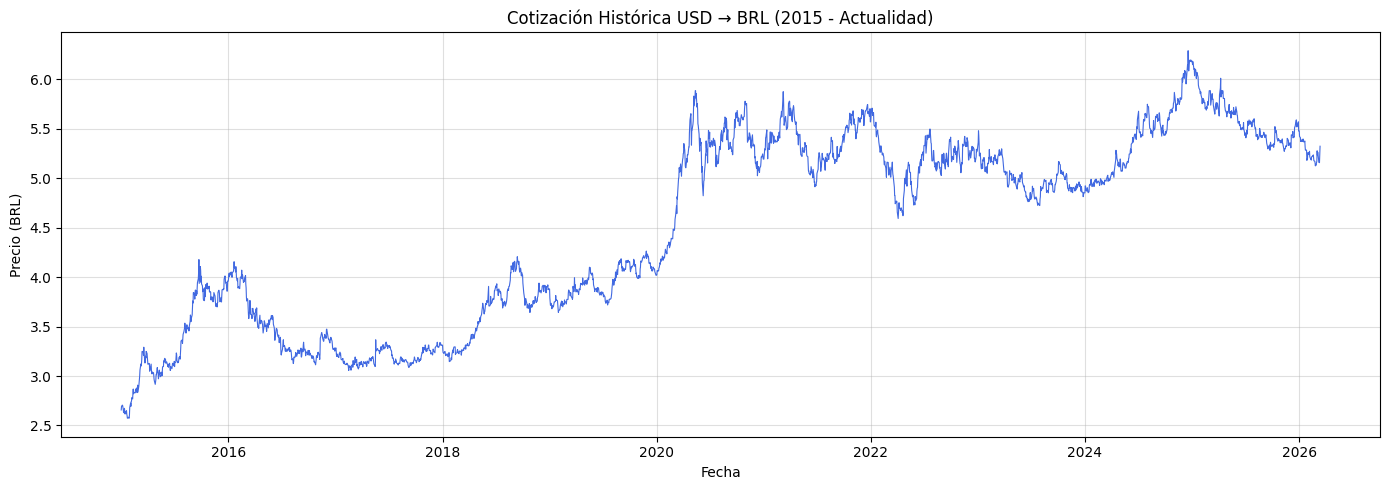

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotización Histórica USD → BRL (2015 - Actualidad)')
plt.xlabel('Fecha')
plt.ylabel('Precio (BRL)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Ingeniería de Características: Ventanas Deslizantes y Normalización

Se aplica la misma técnica de **ventana deslizante** que en el notebook MLP:

> Dados los precios de los últimos **50 días**, predecir el precio del **día 51**.

La diferencia clave está en la **forma del tensor de entrada**:

| Modelo | Forma de X por muestra | Descripción |
|--------|------------------------|-------------|
| MLP    | `(50,)`                | Vector plano — el orden interno no importa |
| LSTM   | `(50, 1)`              | Secuencia de 50 pasos, 1 feature por paso |

El LSTM procesa los 50 días **uno por uno en orden**, actualizando su estado oculto en cada paso. Así el modelo sabe que el día 1 ocurrió antes que el día 50.

In [7]:
# ── Hiperparámetro: longitud de la ventana ─────────────────────────────────────
n_steps = 50   # usamos los últimos 50 días para predecir el día 51
# ──────────────────────────────────────────────────────────────────────────────

# Normalización Min-Max al rango [0, 1]
precios = df['Price'].values.reshape(-1, 1)
scaler  = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios).flatten()

# Construcción de ventanas deslizantes → salida en 3D para LSTM
def crear_ventanas_lstm(serie, n_steps):
    """
    Convierte una serie 1D en pares (X, y) para LSTM.
    X tiene forma (muestras, n_steps, 1)  ← 3D requerido por torch.nn.LSTM
    y tiene forma (muestras, 1)
    """
    X, y = [], []
    for i in range(len(serie) - n_steps):
        X.append(serie[i : i + n_steps])      # ventana de n_steps valores
        y.append(serie[i + n_steps])           # valor siguiente
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    # Añadir dimensión de feature → (muestras, n_steps, 1)
    X = X[:, :, np.newaxis]
    return X, y

X_all, y_all = crear_ventanas_lstm(precios_norm, n_steps)

print(f'Total de muestras generadas: {len(X_all)}')
print(f'Forma de X_all: {X_all.shape}   → (muestras, n_steps, features)')
print(f'Forma de y_all: {y_all.shape}  → (muestras, 1)')

Total de muestras generadas: 2872
Forma de X_all: (2872, 50, 1)   → (muestras, n_steps, features)
Forma de y_all: (2872, 1)  → (muestras, 1)


## 3. División cronológica Train / Validación / Test

In [8]:
# División cronológica Train / Validación / Test  (70% / 15% / 15%)
n_total  = len(X_all)
n_train  = int(n_total * 0.70)
n_val    = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],               y_all[:n_train]
X_valid, y_valid = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]} muestras  →  X: {X_train.shape}')
print(f'Valid : {X_valid.shape[0]} muestras  →  X: {X_valid.shape}')
print(f'Test  : {X_test.shape[0]}  muestras  →  X: {X_test.shape}')

Train : 2010 muestras  →  X: (2010, 50, 1)
Valid : 430 muestras  →  X: (430, 50, 1)
Test  : 432  muestras  →  X: (432, 50, 1)


## 4. Dataset y DataLoader de PyTorch

El `TimeSeriesDataset` ahora almacena tensores 3D `(n_steps, 1)` por muestra, que es lo que `torch.nn.LSTM` espera con `batch_first=True`.

In [9]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        # X: (muestras, n_steps, 1)  —  y: (muestras, 1)
        self.X     = torch.tensor(X, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train and self.y is not None:
            return self.X[ix], self.y[ix]    # (n_steps, 1), (1,)
        return self.X[ix]                    # (n_steps, 1)


dataset = {
    'train': TimeSeriesDataset(X_train, y_train, train=True),
    'eval' : TimeSeriesDataset(X_valid, y_valid, train=True),
    'test' : TimeSeriesDataset(X_test,  y_test,  train=False),
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64),
}

# Verificar forma de un batch
X_sample, y_sample = next(iter(dataloader['train']))
print('Forma de un batch X:', X_sample.shape)   # (64, 50, 1)
print('Forma de un batch y:', y_sample.shape)   # (64, 1)
print('DataLoaders listos.')

Forma de un batch X: torch.Size([64, 50, 1])
Forma de un batch y: torch.Size([64, 1])
DataLoaders listos.


## 5. Pipeline de Entrenamiento y Predicción

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de cómputo: {device}')


def fit(model, dataloader, epochs=50):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:
        # ── Fase de entrenamiento ──────────────────────────────────────────────
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        # ── Fase de validación ─────────────────────────────────────────────────
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        bar.set_description(
            f'loss {np.mean(train_loss):.5f}  val_loss {np.mean(eval_loss):.5f}'
        )


def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X    = batch.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
    return preds


def desnorm(arr):
    """Transforma predicciones del rango [0,1] de vuelta a BRL."""
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


print('Funciones fit, predict y desnorm definidas correctamente.')

Dispositivo de cómputo: cuda
Funciones fit, predict y desnorm definidas correctamente.


## 6. Predicción Naive — Línea Base

El modelo Naive predice que el precio de mañana será igual al precio de hoy:

$$\hat{y}(t+1) = y(t)$$

En la ventana de entrada `X[i]` de forma `(50, 1)`, el último valor `X[i, -1, 0]` corresponde al precio del día `t`. Es la línea base mínima que cualquier modelo debe superar.

MSE Naive (escala real BRL²): 0.001943


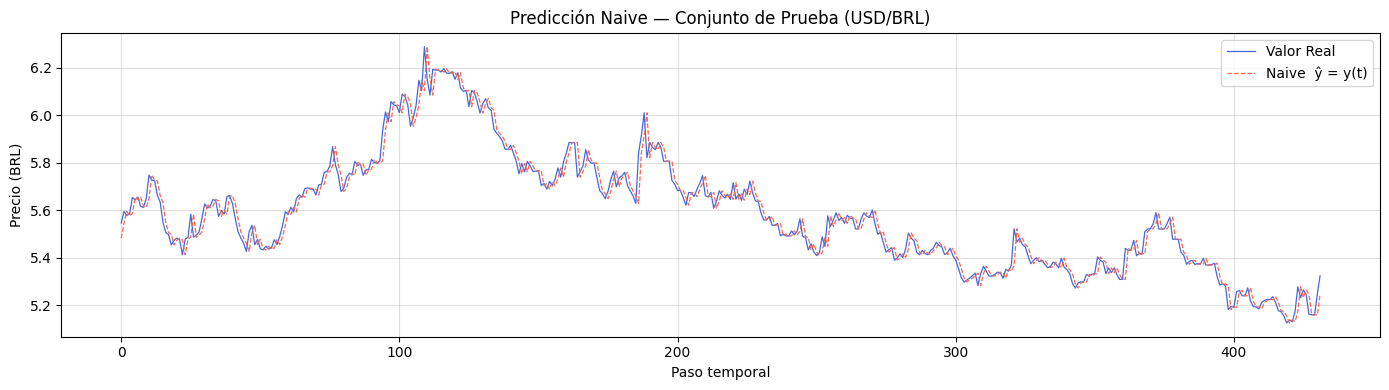

In [11]:
# X_test tiene forma (muestras, n_steps, 1)
# El último paso temporal es X_test[:, -1, 0]  → precio del día t (normalizado)
y_pred_naive_norm = X_test[:, -1, 0].reshape(-1, 1)   # forma (muestras, 1)

# Desnormalizar
y_test_real       = desnorm(y_test)
y_pred_naive_real = desnorm(y_pred_naive_norm)

mse_naive = mean_squared_error(y_test_real, y_pred_naive_real)
print(f'MSE Naive (escala real BRL²): {mse_naive:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',       color='royalblue', linewidth=0.9)
plt.plot(y_pred_naive_real, label='Naive  ŷ = y(t)',  color='tomato',    linewidth=0.9, linestyle='--')
plt.title('Predicción Naive — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Modelo LSTM

### ¿Por qué LSTM y no RNN simple?

La celda RNN simple sufre del problema de **vanishing gradient**: al retropropagar a través de muchos pasos temporales, los gradientes se hacen tan pequeños que los primeros instantes dejan de influir en el aprendizaje. Con 50 pasos de historia, esto es un problema real.

La celda **LSTM** resuelve esto con dos caminos de información:
- **$h_t$** (short-term): estado oculto clásico, pasa de celda en celda.
- **$c_t$** (long-term): "memoria de largo plazo" que fluye con pocos cambios, preservando gradientes.

Tres puertas (`forget`, `input`, `output`) controlan qué información conservar, añadir u olvidar en cada paso.

### Arquitectura

```
Entrada: (batch, 50, 1)          ← secuencia de 50 pasos, 1 precio por paso
    ↓
LSTM(input=1, hidden=64, layers=2, dropout=0.2)
    ↓
Tomar solo la salida del ÚLTIMO paso temporal: h[-1] → (batch, 64)
    ↓
Linear(64 → 1)
    ↓
Salida: (batch, 1)               ← precio predicho del día 51
```

In [12]:
class LSTMModel(torch.nn.Module):
    """
    LSTM de 2 capas para predicción one-step-ahead.
    
    Entrada : (batch, n_steps, input_size=1)
    Salida  : (batch, 1)  →  precio normalizado del día siguiente
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = torch.nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,      # dropout entre capas LSTM (no aplica si num_layers=1)
            batch_first = True           # esperamos (batch, seq, features)
        )
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, n_steps, 1)
        out, (h_n, c_n) = self.lstm(x)
        # out:  (batch, n_steps, hidden_size)  — salida en cada paso temporal
        # h_n:  (num_layers, batch, hidden_size) — último estado oculto por capa
        # Tomamos solo la salida del ÚLTIMO paso temporal
        last = out[:, -1, :]             # (batch, hidden_size)
        return self.fc(last)             # (batch, 1)


lstm_model = LSTMModel()
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'\nParámetros entrenables: {total_params:,}')

# Verificar dimensiones con un batch de prueba
with torch.no_grad():
    test_in  = torch.randn(8, n_steps, 1)   # batch de 8 muestras
    test_out = lstm_model(test_in)
    print(f'\nVerificación de dimensiones:')
    print(f'  Entrada : {test_in.shape}  → (batch, n_steps, features)')
    print(f'  Salida  : {test_out.shape}  → (batch, 1)')

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros entrenables: 50,497

Verificación de dimensiones:
  Entrada : torch.Size([8, 50, 1])  → (batch, n_steps, features)
  Salida  : torch.Size([8, 1])  → (batch, 1)


### Exploración de los parámetros internos del LSTM

A diferencia de una capa `Linear`, cada capa LSTM tiene **4 matrices de pesos** (una por puerta: forget, input, output, y la celda candidata `g`). El parámetro `weight_ih_l0` contiene las 4 matrices apiladas para la **entrada** y `weight_hh_l0` para el **estado oculto**.

In [13]:
# Pesos de la capa 0 para la entrada x  → (4 * hidden_size, input_size)
print('weight_ih_l0 (entrada → gates)  :', lstm_model.lstm.weight_ih_l0.shape)

# Pesos de la capa 0 para el estado oculto h → (4 * hidden_size, hidden_size)
print('weight_hh_l0 (h_{t-1} → gates) :', lstm_model.lstm.weight_hh_l0.shape)

# Interpretación: 4 * 64 = 256  →  64 pesos para cada una de las 4 puertas
print(f'\nSon 4 × {lstm_model.lstm.hidden_size} = {4 * lstm_model.lstm.hidden_size} filas')
print('Orden: [forget gate | input gate | cell gate | output gate]')

weight_ih_l0 (entrada → gates)  : torch.Size([256, 1])
weight_hh_l0 (h_{t-1} → gates) : torch.Size([256, 64])

Son 4 × 64 = 256 filas
Orden: [forget gate | input gate | cell gate | output gate]


### Entrenamiento

In [14]:
fit(lstm_model, dataloader, epochs=50)

loss 0.00056  val_loss 0.00027: 100%|██████████| 50/50 [00:07<00:00,  6.90it/s]


### Predicción y evaluación

MSE LSTM (escala real BRL²): 0.007076


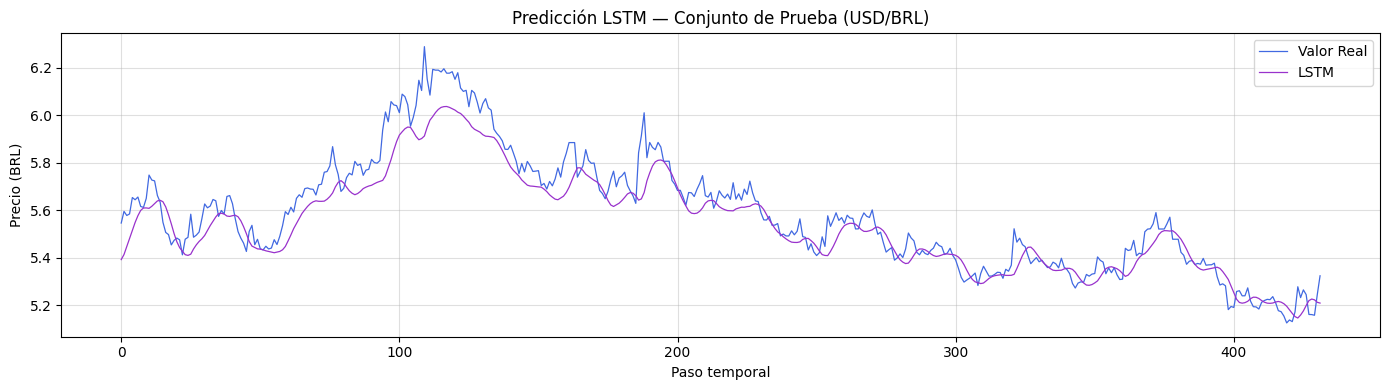

In [15]:
y_pred_lstm_norm = predict(lstm_model, dataloader['test']).cpu().numpy()
y_pred_lstm_real = desnorm(y_pred_lstm_norm)

mse_lstm = mean_squared_error(y_test_real, y_pred_lstm_real)
print(f'MSE LSTM (escala real BRL²): {mse_lstm:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',  color='royalblue', linewidth=0.9)
plt.plot(y_pred_lstm_real,  label='LSTM',        color='darkorchid', linewidth=0.9)
plt.title('Predicción LSTM — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Comparación Final: Naive vs LSTM

In [16]:
print('=' * 50)
print(f'  {"Modelo":<20}  MSE (BRL²)   RMSE (BRL)')
print('=' * 50)
for nombre, mse in [('Naive  ŷ = y(t)', mse_naive), ('LSTM', mse_lstm)]:
    rmse = np.sqrt(mse)
    print(f'  {nombre:<20}  {mse:.6f}   {rmse:.4f}')
print('=' * 50)

  Modelo                MSE (BRL²)   RMSE (BRL)
  Naive  ŷ = y(t)       0.001943   0.0441
  LSTM                  0.007076   0.0841


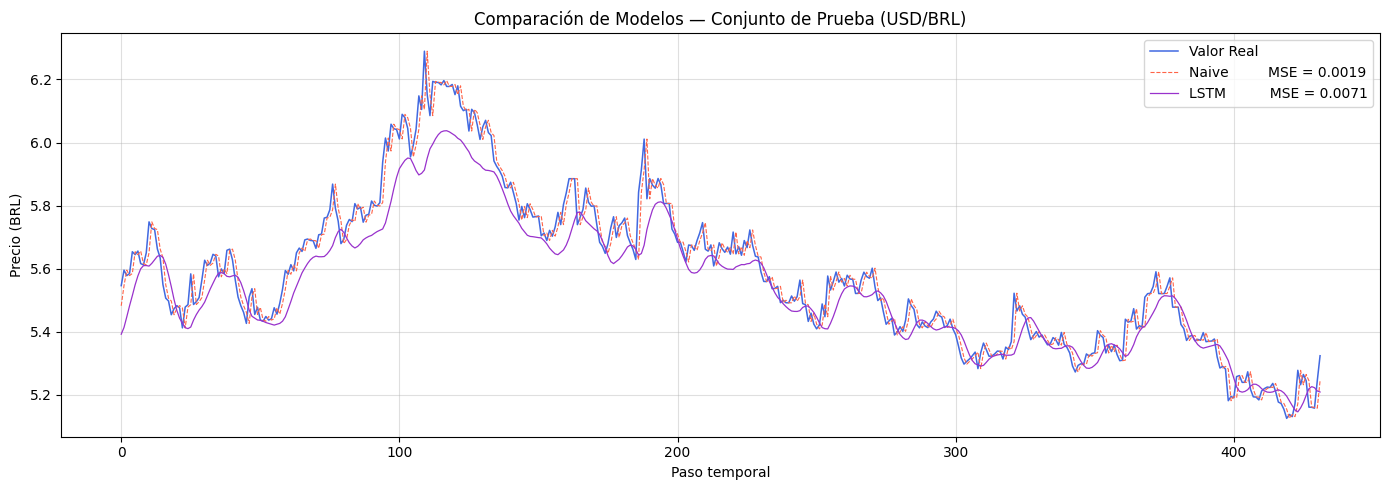

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real,       label='Valor Real',
         color='royalblue',  linewidth=1.1)
plt.plot(y_pred_naive_real, label=f'Naive         MSE = {mse_naive:.4f}',
         color='tomato',     linewidth=0.8, linestyle='--')
plt.plot(y_pred_lstm_real,  label=f'LSTM          MSE = {mse_lstm:.4f}',
         color='darkorchid', linewidth=0.9)
plt.title('Comparación de Modelos — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Conclusiones

### Diferencia arquitectónica clave: MLP vs LSTM

| Aspecto | MLP | LSTM |
|---|---|---|
| Forma de entrada | `(batch, 50)` — vector plano | `(batch, 50, 1)` — secuencia ordenada |
| Orden temporal | Ignorado arquitectónicamente | Procesado paso a paso |
| Estado interno | Ninguno | $h_t$ (short-term) + $c_t$ (long-term) |
| Parámetros (aprox.) | ~8 000 (MLP profundo) | ~36 000 (LSTM 2 capas hidden=64) |
| Dependencias largas | Limitadas | Preservadas gracias a $c_t$ |

### ¿Por qué el LSTM tiene ventaja?

El tipo de cambio USD/BRL tiene **dependencias temporales**: el precio de hoy no solo depende del precio de ayer, sino de tendencias de semanas anteriores. La celda LSTM, gracias al camino de largo plazo $c_t$, puede preservar esa memoria a través de los 50 pasos sin que los gradientes desaparezcan.

### Posibles mejoras adicionales

- **Aumentar `hidden_size`** (128, 256) para más capacidad de representación.
- **Añadir features** (medias móviles, volatilidad) como canales adicionales: entrada `(batch, 50, k_features)`.
- **Early Stopping + ReduceLROnPlateau** para evitar sobreajuste y ajustar el LR dinámicamente.
- **GRU** como alternativa más eficiente: mismas ganancias con ~25% menos parámetros.